# 04_206 · Qwen en cascada y jerárquico multitarea · cuatro daños

Compara el Qwen plano de `04_205` con dos estructuras construidas sobre su adaptador terminado: una cascada logística y una cabeza neuronal jerárquica multitarea. Este cuaderno **no debe ejecutarse hasta que `04_205` termine**. No modifica su adaptador ni realiza un segundo fine-tuning end-to-end.

El arranque híbrido usa el workspace en local y, en Colab, código fijado de GitHub con artefactos mínimos persistentes en Google Drive. Al comenzar en Windows verifica los resultados, la selección calibrada y el adaptador operativo de `04_205`; si Drive contiene una extensión coherente del historial local, los sincroniza hacia `D:` con hashes SHA-256 antes de importar los módulos.

In [4]:
from pathlib import Path
from importlib.util import find_spec
import importlib
import hashlib, json, os, shutil, subprocess, sys
import pandas as pd
from IPython.display import display, Markdown, Image
REPO_URL = 'https://github.com/lkoc/Trabajo_PLN-MIA-Grupo4.git'
GIT_COMMIT = 'ce33b5efd797eef0809e9ff8694c90220cd81e9d'
PROJECT_NAME, DRIVE_BUNDLE_NAME = 'Trabajo_PLN-MIA-Grupo4', 'PLN_colab_04_artifacts'
WINDOWS_DRIVE_BUNDLE = Path(r'G:\My Drive\PLN_colab_04_artifacts')
QWEN_RESULT_RELATIVE = Path('resultados/metricas/qwen3_06b_lora_acoso_amenaza_4/finetuning.json')
QWEN_SELECTION_RELATIVE = Path('resultados/metricas/qwen3_06b_lora_acoso_amenaza_4/seleccion_operativa_validacion.json')

def _sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

def _read_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8-sig'))

def _validate_qwen_bundle(base):
    result_path, selection_path = base / QWEN_RESULT_RELATIVE, base / QWEN_SELECTION_RELATIVE
    if not result_path.is_file() or not selection_path.is_file(): return None
    result, selection = _read_json(result_path), _read_json(selection_path)
    if result.get('status') != 'completed' or int(result.get('epochs_completed', 0)) < 4:
        return None
    if selection.get('test_consulted_for_selection') is not False:
        raise RuntimeError(f'La selección Qwen de {base} no acredita aislamiento de test.')
    selected = next((row for row in selection.get('candidates', []) if int(row['epoch']) == int(selection['selected_epoch'])), None)
    if selected is None: raise RuntimeError(f'Selección Qwen incompleta en {base}.')
    adapter = base / selection['selected_adapter']
    state, weights = adapter / 'training_state.json', adapter / 'adapter_model.safetensors'
    if not state.is_file() or not weights.is_file(): raise FileNotFoundError(f'Adaptador seleccionado incompleto en {adapter}.')
    if _sha256(state) != selected['adapter_training_state_sha256'] or _sha256(weights) != selected['adapter_weights_sha256']:
        raise RuntimeError(f'Hashes inválidos en el adaptador seleccionado de {base}.')
    return {'result': result, 'selection': selection, 'selected_epoch': int(selection['selected_epoch'])}

def _sync_qwen_04_205_from_drive(root):
    if sys.platform != 'win32': return {'status': 'not_windows', 'copied': False}
    if not WINDOWS_DRIVE_BUNDLE.is_dir():
        return {'status': 'drive_unavailable', 'copied': False, 'drive': str(WINDOWS_DRIVE_BUNDLE)}
    remote = _validate_qwen_bundle(WINDOWS_DRIVE_BUNDLE)
    if remote is None:
        return {'status': 'drive_incomplete', 'copied': False}
    local_result_path = root / QWEN_RESULT_RELATIVE
    reason = None
    if not local_result_path.is_file():
        reason = 'resultado local ausente'
    else:
        local_result = _read_json(local_result_path)
        if local_result.get('dataset_sha256') != remote['result'].get('dataset_sha256'):
            raise RuntimeError('Drive y D contienen resultados Qwen de datasets diferentes; no se sobrescribió nada.')
        local_epochs = int(local_result.get('epochs_completed', 0))
        remote_epochs = int(remote['result'].get('epochs_completed', 0))
        local_history, remote_history = local_result.get('history', []), remote['result'].get('history', [])
        if local_epochs > remote_epochs:
            return {'status': 'local_newer', 'copied': False, 'local_epochs': local_epochs, 'drive_epochs': remote_epochs}
        if local_history != remote_history[:len(local_history)]:
            raise RuntimeError('Drive y D tienen historiales Qwen divergentes; no se sobrescribió nada.')
        if remote_epochs > local_epochs:
            reason = f'Drive extiende {local_epochs} -> {remote_epochs} épocas'
        else:
            local = _validate_qwen_bundle(root)
            if local is None:
                reason = 'faltan selección o adaptador operativo local'
            elif _sha256(root / QWEN_SELECTION_RELATIVE) != _sha256(WINDOWS_DRIVE_BUNDLE / QWEN_SELECTION_RELATIVE):
                raise RuntimeError('Drive y D tienen selecciones operativas diferentes; no se sobrescribió nada.')
            else:
                return {'status': 'up_to_date', 'copied': False, 'epochs': local_epochs, 'selected_epoch': local['selected_epoch']}
    recovery_script = root / 'scripts_auxiliares' / 'recuperar_resultados_colab_04_20x.ps1'
    powershell = shutil.which('powershell') or shutil.which('powershell.exe')
    if powershell is None or not recovery_script.is_file():
        raise RuntimeError('La sincronización es necesaria, pero no está disponible PowerShell o el script recuperador.')
    command = [powershell, '-NoProfile', '-ExecutionPolicy', 'Bypass', '-File', str(recovery_script),
               '-Workspace', str(root), '-DriveBundle', str(WINDOWS_DRIVE_BUNDLE), '-Qwen04_205Only', '-Force']
    completed = subprocess.run(command, text=True, capture_output=True)
    if completed.returncode != 0:
        raise RuntimeError('Falló la sincronización Drive -> D:\n' + (completed.stderr or completed.stdout))
    local = _validate_qwen_bundle(root)
    if local is None or _sha256(root / QWEN_RESULT_RELATIVE) != _sha256(WINDOWS_DRIVE_BUNDLE / QWEN_RESULT_RELATIVE):
        raise RuntimeError('La copia terminó, pero la verificación final de 04_205 falló.')
    return {'status': 'synchronized', 'copied': True, 'reason': reason,
            'epochs': int(local['result']['epochs_completed']), 'selected_epoch': local['selected_epoch']}

def _bootstrap_04_20x():
    in_colab = find_spec('google.colab') is not None
    if not in_colab:
        start = Path.cwd().resolve()
        root = next((p for p in (start, *start.parents) if (p / 'scripts_auxiliares').is_dir()), None)
        if root is None: raise FileNotFoundError('No se encontró la raíz local del proyecto.')
        sync_info = _sync_qwen_04_205_from_drive(root)
        return root, False, root, 'working-tree-local', sync_info
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    artifacts = Path('/content/drive/MyDrive') / DRIVE_BUNDLE_NAME
    manifest_path = artifacts / 'MANIFIESTO_ARTEFACTOS_04_20X.json'
    if not manifest_path.is_file(): raise FileNotFoundError('Falta el bundle de Drive; ejecute sincronizar_04_20x_google_drive.ps1 en Windows.')
    manifest = json.loads(manifest_path.read_text(encoding='utf-8-sig'))
    missing = [r['path'] for r in manifest['files'] if not (artifacts / r['path']).is_file()]
    if missing: raise FileNotFoundError('Bundle incompleto en Drive:\n' + '\n'.join(missing))
    root = Path('/content') / PROJECT_NAME
    if not (root / '.git').is_dir():
        if root.exists(): raise RuntimeError(f'Ruta no administrada ya existente: {root}')
        subprocess.run(['git', 'clone', '--filter=blob:none', '--no-checkout', REPO_URL, str(root)], check=True)
    current = subprocess.check_output(['git', '-C', str(root), 'rev-parse', 'HEAD'], text=True).strip()
    if current != GIT_COMMIT:
        subprocess.run(['git', '-C', str(root), 'fetch', '--depth', '1', 'origin', GIT_COMMIT], check=True)
    subprocess.run(['git', '-C', str(root), 'sparse-checkout', 'set', 'scripts_auxiliares'], check=True)
    subprocess.run(['git', '-C', str(root), 'checkout', '--detach', GIT_COMMIT], check=True)
    for name in ('datos', 'modelos', 'resultados'):
        local, target = root / name, artifacts / name
        target.mkdir(parents=True, exist_ok=True)
        if local.is_symlink() and local.resolve() == target.resolve(): continue
        if local.is_symlink(): local.unlink()
        elif local.exists(): raise RuntimeError(f'Ruta de artefactos no administrada: {local}')
        local.symlink_to(target, target_is_directory=True)
    return root, True, artifacts, GIT_COMMIT, {'status': 'drive_direct', 'copied': False}
ROOT, IN_COLAB, ARTIFACT_ROOT, CODE_VERSION, QWEN_SYNC_INFO = _bootstrap_04_20x()
if IN_COLAB:
    packages = {'transformers': 'transformers>=4.51,<6', 'sklearn': 'scikit-learn>=1.4', 'peft': 'peft>=0.15,<1'}
    missing_packages = [p for m, p in packages.items() if find_spec(m) is None]
    if missing_packages: subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *missing_packages], check=True)
    # TorchAO es opcional para este LoRA float32. Algunas imágenes de Colab
    # incluyen una versión antigua que PEFT rechaza incluso sin usar cuantización.
    try:
        from peft import import_utils as _peft_import_utils
        _peft_import_utils.is_torchao_available()
    except ImportError as error:
        if 'incompatible version of torchao' not in str(error): raise
        try:
            from importlib.metadata import version as _package_version
            _torchao_version = _package_version('torchao')
        except Exception:
            _torchao_version = 'desconocida'
        subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y', '-q', 'torchao'], check=True)
        for _module in tuple(sys.modules):
            if _module == 'torchao' or _module.startswith('torchao.') or _module == 'peft' or _module.startswith('peft.'):
                sys.modules.pop(_module, None)
        importlib.invalidate_caches()
        if find_spec('torchao') is not None: raise RuntimeError('TorchAO incompatible continúa importable; reinicie el runtime.')
        print(f'TorchAO {_torchao_version} incompatible retirado; PEFT usará LoRA estándar.')
os.environ['PLN_PROJECT_ROOT'], os.environ['PLN_ARTIFACT_ROOT'] = str(ROOT), str(ARTIFACT_ROOT)
os.chdir(ROOT)
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from scripts_auxiliares import experimentos_qwen_jerarquico_4 as qh
from scripts_auxiliares import entrenar_qwen_acoso_amenaza as q4
print('Entorno:', 'Google Colab híbrido' if IN_COLAB else 'local')
print('Código:', ROOT, CODE_VERSION)
print('Artefactos persistentes:', ARTIFACT_ROOT)
print('Verificación Drive -> D de 04_205:', QWEN_SYNC_INFO)
print('Estado de entrenamiento 04_205 (best_epoch = mejor PR-AUC):', q4.resume_status())
_startup_selection_path = q4.METRICS_DIR / 'seleccion_operativa_validacion.json'
if _startup_selection_path.is_file():
    _startup_selection = _read_json(_startup_selection_path)
    print('Selección operativa calibrada:', {
        'selected_epoch': _startup_selection['selected_epoch'],
        'recall_target': _startup_selection['recall_target'],
        'test_consulted_for_selection': _startup_selection['test_consulted_for_selection'],
    })
print('Objetivos:', qh.TARGET_LABELS)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entorno: Google Colab híbrido
Código: /content/Trabajo_PLN-MIA-Grupo4 ce33b5efd797eef0809e9ff8694c90220cd81e9d
Artefactos persistentes: /content/drive/MyDrive/PLN_colab_04_artifacts
Verificación Drive -> D de 04_205: {'status': 'drive_direct', 'copied': False}
Estado de entrenamiento 04_205 (best_epoch = mejor PR-AUC): {'status': 'completed', 'epochs_completed': 4, 'best_epoch': 2, 'adapter': 'modelos/qwen3_06b_lora_acoso_amenaza_4/best_adapter'}
Selección operativa calibrada: {'selected_epoch': 3, 'recall_target': 0.95, 'test_consulted_for_selection': False}
Objetivos: ['RACISMO_DISCRIMINACION', 'ACOSO_GENERO_IDENTIDAD', 'ACOSO_AMENAZA', 'CONTENIDO_SEXUAL']


## 1. Contrato y requisito

La siguiente celda se detiene deliberadamente si `04_205` no completó efectivamente las cuatro épocas o todavía no calibró y seleccionó sus dos mejores checkpoints usando sólo validación. Los experimentos reutilizan el adaptador operativo seleccionado, no el alias histórico `best_adapter`. También se verifica que Qwen y los experimentos jerárquicos compartan el mismo hash de dataset y los mismos splits.

In [5]:
USE_EXPANDED_SAFE = True
q4.MAX_EPOCHS = 4
training_04_205 = json.loads(q4.TRAINING_RESULT_PATH.read_text(encoding='utf-8'))
if int(training_04_205.get('epochs_completed', 0)) < 4:
    raise RuntimeError('04_205 aún no completó la época 4 forzada.')
selection_path = q4.METRICS_DIR / 'seleccion_operativa_validacion.json'
if not selection_path.is_file():
    raise FileNotFoundError('04_205 aún no calibró ni seleccionó los dos mejores checkpoints.')
selection_04_205 = json.loads(selection_path.read_text(encoding='utf-8'))
if selection_04_205.get('test_consulted_for_selection') is not False:
    raise RuntimeError('La selección de 04_205 no acredita aislamiento de test.')
selected_adapter_dir = ROOT / selection_04_205['selected_adapter']
selected_state = selected_adapter_dir / 'training_state.json'
selected_row = next(row for row in selection_04_205['candidates'] if row['epoch'] == selection_04_205['selected_epoch'])
if q4.sha256_file(selected_state) != selected_row['adapter_training_state_sha256']:
    raise RuntimeError('El adaptador seleccionado cambió después de calibrarlo.')
if q4.sha256_file(selected_adapter_dir / 'adapter_model.safetensors') != selected_row['adapter_weights_sha256']:
    raise RuntimeError('Los pesos seleccionados cambiaron después de calibrarlos.')

context = qh.load_context(use_expanded_safe=USE_EXPANDED_SAFE)
# Compatibilidad con el commit fijo de Colab: su extractor llamaba a
# load_best_model. Se redirige al ganador operativo y se cambia el hash
# del cache para no reutilizar representaciones de otro checkpoint.
if 'adapter_directory' not in context['qwen']:
    selected_artifact = qh._artifact(selected_state)
    context['qwen']['best_adapter_state'] = selected_artifact
    context['qwen']['adapter_state'] = selected_artifact
    context['qwen']['adapter_directory'] = str(selected_adapter_dir.relative_to(ROOT)).replace('\\', '/')
    context['qwen']['selection'] = selection_04_205
    def _load_operational_model(target_device=None):
        state = json.loads(selected_state.read_text(encoding='utf-8'))
        return q4.load_adapter(selected_adapter_dir, target_device or q4.device()), state
    q4.load_best_model = _load_operational_model
display(context['qwen'])
display(context['expansion'])
assert context['qwen_audit']['dataset_sha256'] == context['frozen']['dataset_sha256']
assert context['expansion']['validation_or_test_videos_used'] is False

{'training': {'status': 'completed',
  'completed_at': '2026-07-29T15:43:32+00:00',
  'model': {'key': 'qwen3_06b_lora',
   'model_id': 'Qwen/Qwen3-0.6B-Base',
   'revision': 'da87bfb608c14b7cf20ba1ce41287e8de496c0cd',
   'prefix': '',
   'label': 'Qwen3-0.6B-Base + LoRA'},
  'method': 'LoRA parameter-efficient fine-tuning',
  'taxonomy': {'semantic_labels': ['SEGURO',
    'RACISMO_DISCRIMINACION',
    'ACOSO_GENERO_IDENTIDAD',
    'ACOSO_AMENAZA',
    'CONTENIDO_SEXUAL'],
   'trained_damage_targets': ['RACISMO_DISCRIMINACION',
    'ACOSO_GENERO_IDENTIDAD',
    'ACOSO_AMENAZA',
    'CONTENIDO_SEXUAL'],
   'merge': 'ACOSO_AMENAZA = ACOSO_PERSONAL union AMENAZA_DIRECTA',
   'safe_is_derived': True},
  'dataset': 'datos/model_ready/transformer_grueso/dataset_balanceado_4a1_particionado.jsonl',
  'dataset_sha256': 'df2ac01183271e44b6dcfb9cb4850bd6b1ef1cd11d9fc51c881be944670ef20f',
  'training_fingerprint_sha256': '740b4e9c100756954f3f0734a7dcfb760dc5c77bd15650908a2a490078face84',
  'traini

{'purpose': 'binary_gate_negative_diversity_without_evaluation_video_leakage',
 'selection': 'all integrated SEGURO excluding validation/test videos',
 'integrated_dataset': 'datos/model_ready/transformer_grueso/dataset_integrado_todas_pasadas.jsonl',
 'integrated_dataset_sha256': '3f01b76d285d4cdd2a0922df1d2437a7f01abc4e05e2699c218b1f5faaba2069',
 'matched_train_rows': 24701,
 'matched_train_safe_rows': 19757,
 'additional_safe_rows': 57117,
 'additional_safe_from_mapped_train_videos': 56186,
 'additional_safe_from_unassigned_train_only_videos': 931,
 'expanded_gate_train_rows': 81818,
 'expanded_gate_safe_rows': 76874,
 'expanded_gate_damage_rows': 4944,
 'expanded_gate_train_videos': 2334,
 'additional_chunk_ids_sha256': '37acc5bb08032a005b26b66416993b80c7be2af2d9c2efd106db02da4e937b02',
 'validation_or_test_videos_used': False}

## 2. Representaciones Qwen congeladas

Se guardan los 21 logits de `04_205`: cuatro operativos, 14 finos auxiliares y tres flags. Son representaciones generadas únicamente a partir del texto; las etiquetas no son entradas. El cache registra hash del adaptador y de los IDs.

Con `USE_EXPANDED_SAFE=True`, Qwen debe inferir también los `SEGURO` adicionales permitidos. Esto puede tardar bastante en CPU, pero se realiza una sola vez y luego se reutiliza. Aunque el corpus tiene más de 110 mil `SEGURO`, train usa sólo aquellos cuyos videos no aparecen en validation/test.

In [6]:
FORCE_FEATURES = False
features = qh.extract_features(context, force=FORCE_FEATURES)
display({split: values.shape for split, values in features.items()})

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[transformers] Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B-Base
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Qwen congelado · train_expanded:   0%|          | 0/20455 [00:00<?, ?lote/s]

Qwen congelado · validation:   0%|          | 0/1331 [00:00<?, ?lote/s]

Qwen congelado · test:   0%|          | 0/1323 [00:00<?, ?lote/s]

{'train_expanded': (81818, 21), 'validation': (5324, 21), 'test': (5290, 21)}

## 3. Dos diseños Qwen jerárquicos

La cascada entrena una puerta binaria con todos los negativos permitidos y cuatro cabezas condicionales con daños y negativos difíciles. El multitarea usa una capa compartida de 32 unidades, cabeza binaria y cuatro cabezas temáticas. La pérdida temática se enmascara en `SEGURO` adicional; sólo la cabeza binaria aprovecha esos chunks.

Ambos modelos fijan umbrales en validation y se comparan con las probabilidades calibradas del Qwen plano sobre exactamente el mismo test. La inferencia estadística usa bootstrap pareado por videos.

In [7]:
FORCE = False
BOOTSTRAP_REPLICATES = 1_000
result = qh.run_experiment(
    force=FORCE,
    use_expanded_safe=USE_EXPANDED_SAFE,
    bootstrap_replicates=BOOTSTRAP_REPLICATES,
)
display(result['selection'])
display(result['paired_decisions_vs_qwen_flat'])

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[transformers] Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B-Base
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Qwen congelado · train_expanded:   0%|          | 0/20455 [00:00<?, ?lote/s]

Qwen congelado · validation:   0%|          | 0/1331 [00:00<?, ?lote/s]

Qwen congelado · test:   0%|          | 0/1323 [00:00<?, ?lote/s]

...

Qwen head multitarea · época 30/30:   0%|          | 0/160 [00:00<?, ?lote/s]

bootstrap pareado por video:   0%|          | 0/1000 [00:00<?, ?réplica/s]

bootstrap pareado por video:   0%|          | 0/1000 [00:00<?, ?réplica/s]

{'partition': 'validation',
 'metric': 'damage_pr_auc_macro',
 'winner_key': 'qwen_frozen_joint',
 'winner_label': 'Qwen congelado + cabeza jerárquica multitarea',
 'test_used_for_selection': False}

{'qwen_frozen_cascade': {'rule': 'Mejora sólo si el IC95% del delta PR-AUC macro es > 0 y el límite superior del delta de tasa de falsos negativos es <= 0.',
  'status': 'modelo_plano_superior_en_pr_auc_macro',
  'replace_flat_model': False,
  'autonomous_deployment_supported': False,
  'reason_autonomy': 'El test conserva etiquetas mayormente LLM y prevalencia 4:1; se requiere un gold standard humano independiente y un piloto prospectivo.'},
 'qwen_frozen_joint': {'rule': 'Mejora sólo si el IC95% del delta PR-AUC macro es > 0 y el límite superior del delta de tasa de falsos negativos es <= 0.',
  'status': 'modelo_plano_superior_en_pr_auc_macro',
  'replace_flat_model': False,
  'autonomous_deployment_supported': False,
  'reason_autonomy': 'El test conserva etiquetas mayormente LLM y prevalencia 4:1; se requiere un gold standard humano independiente y un piloto prospectivo.'}}

,model_key,modelo,split,n,exact_match,jaccard_samples,pr_auc_macro_semantic,damage_pr_auc_macro,damage_precision_micro,damage_recall_micro,damage_f1_micro,damage_f1_macro,any_damage_precision,any_damage_recall,any_damage_f1,missed_damage_as_safe
0,qwen_frozen_cascade,Qwen congelado + cascada calibrada,validation,5324,0.811608,0.831502,0.616074,0.529454,0.547761,0.521677,0.534401,0.545109,0.664751,0.643785,0.654100,384
1,qwen_frozen_cascade,Qwen congelado + cascada calibrada,test,5290,0.811153,0.830829,0.624444,0.537934,0.521773,0.509491,0.515559,0.518363,0.652736,0.630163,0.641251,385
2,qwen_frozen_joint,Qwen congelado + cabeza jerárquica multitarea,validation,5324,0.798648,0.826039,0.622601,0.537371,0.488849,0.576404,0.529028,0.543889,0.658041,0.660482,0.659259,366
3,qwen_frozen_joint,Qwen congelado + cabeza jerárquica multitarea,test,5290,0.795274,0.823440,0.619757,0.532002,0.464508,0.566439,0.510434,0.516978,0.641001,0.639769,0.640385,375
4,qwen4_flat,Qwen 04_205 plano,validation,5324,0.799399,0.819575,0.627487,0.543217,0.515782,0.545842,0.530387,0.540792,0.623932,0.677180,0.649466,348
5,qwen4_flat,Qwen 04_205 plano,test,5290,0.796219,0.819360,0.635954,0.552014,0.497305,0.560364,0.526955,0.534569,0.612543,0.684918,0.646712,328


,epoch,training_loss,validation_damage_pr_auc_macro,validation_damage_f1_macro,validation_binary_pr_auc,thresholds
0,1,0.526197,0.488885,0.521644,0.674845,"[0.42499999999999993, 0.39999999999999997, 0.3..."
1,2,0.368412,0.499762,0.526117,0.677507,"[0.44999999999999996, 0.44999999999999996, 0.3..."
2,3,0.328482,0.503032,0.529778,0.680634,"[0.35, 0.42499999999999993, 0.3749999999999999..."
3,4,0.312730,0.512435,0.533797,0.690923,"[0.475, 0.42499999999999993, 0.35, 0.575]"
4,5,0.304743,0.515849,0.532313,0.694250,"[0.49999999999999994, 0.49999999999999994, 0.3..."
5,6,0.299884,0.518466,0.534418,0.696222,"[0.475, 0.37499999999999994, 0.35, 0.65]"
6,7,0.297421,0.520182,0.533292,0.696119,"[0.37499999999999994, 0.49999999999999994, 0.3..."
7,8,0.295009,0.521633,0.536292,0.696653,"[0.35, 0.39999999999999997, 0.35, 0.5499999999..."
8,9,0.292580,0.525278,0.538948,0.700226,"[0.475, 0.44999999999999996, 0.324999999999999..."
9,10,0.290952,0.525310,0.540406,0.700517,"[0.42499999999999993, 0.475, 0.324999999999999..."


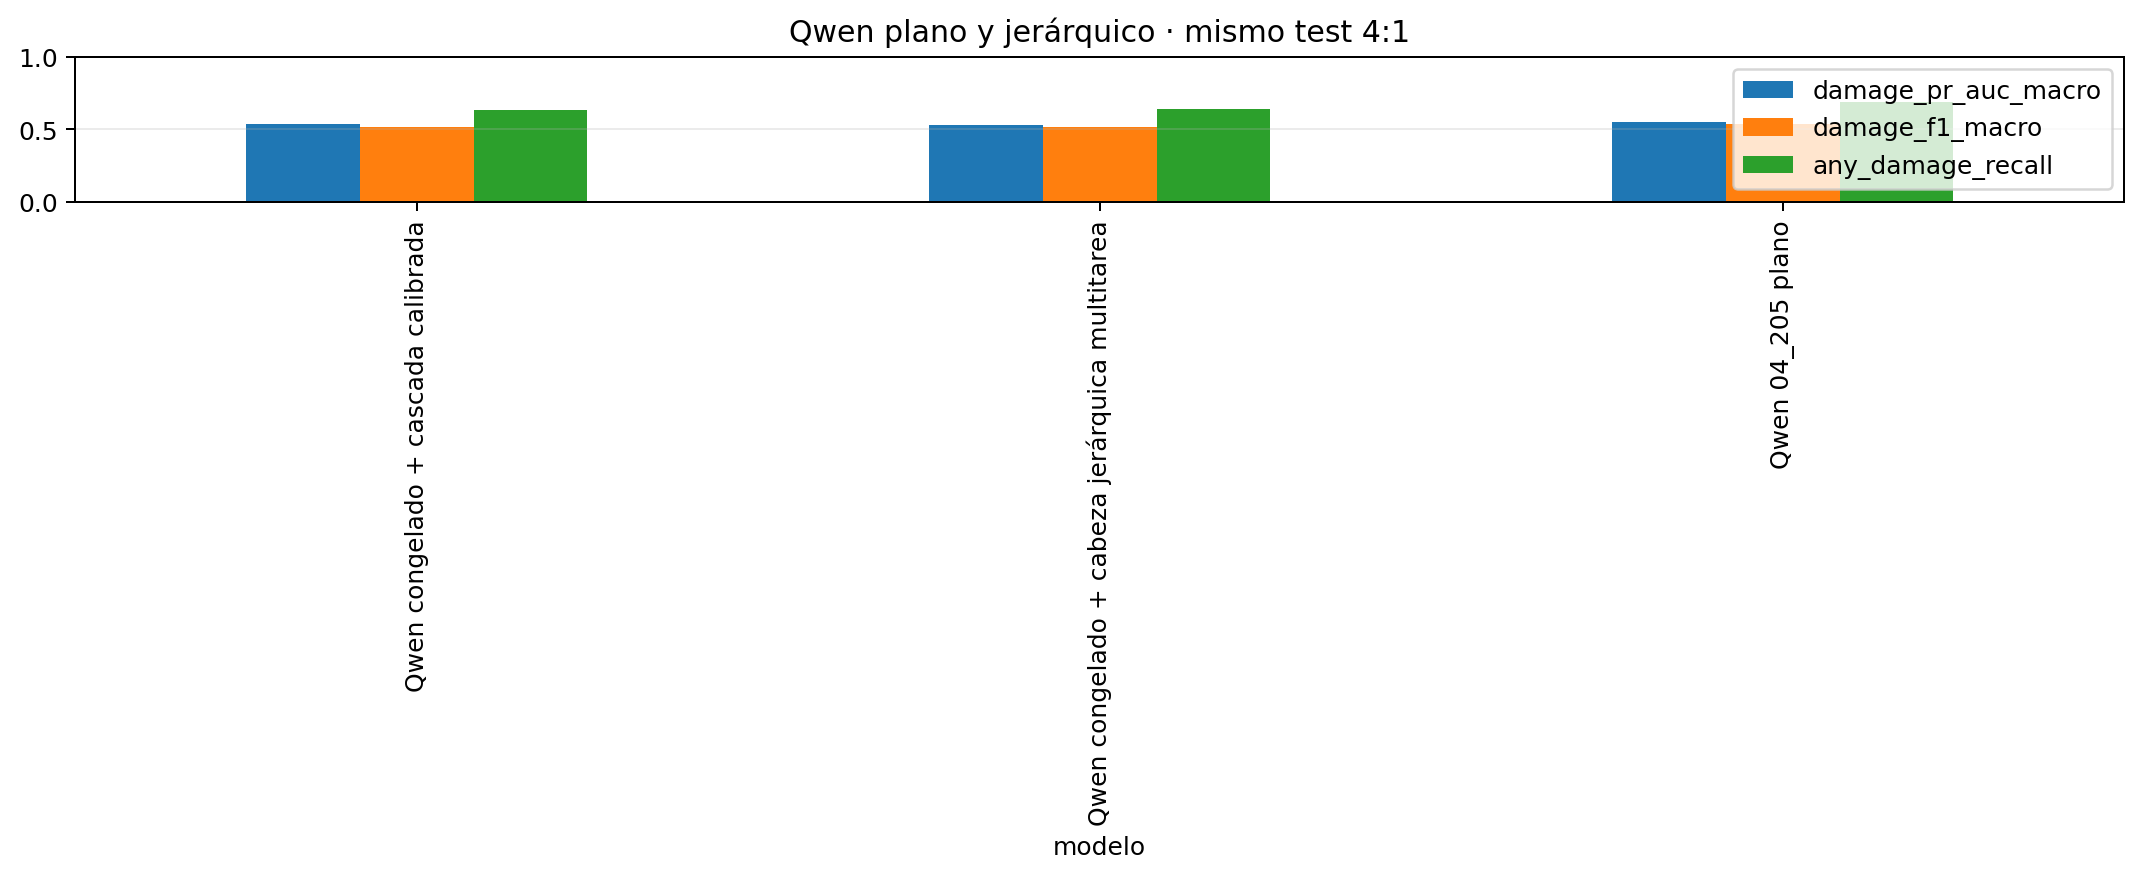

In [8]:
comparison = pd.read_csv(qh.METRICS_DIR / 'comparacion.csv')
display(comparison)
display(pd.DataFrame(result['models']['qwen_frozen_joint']['training']['history']))
display(Image(filename=str(qh.FIGURES_DIR / 'comparacion_test.png')))

In [9]:
display(Markdown(
    f'**Resultado:** `{qh.RESULT_PATH.relative_to(ROOT)}`  \n'
    f'**Informe:** `{qh.REPORT_PATH.relative_to(ROOT)}`  \n'
    f'**Modelos:** `{qh.MODEL_DIR.relative_to(ROOT)}`'
))

**Resultado:** `resultados/metricas/qwen_jerarquico_4/resultado.json`  
**Informe:** `resultados/INFORME_QWEN_JERARQUICO_4.md`  
**Modelos:** `modelos/qwen_jerarquico_4`

In [10]:
# Tras ejecutar el arranque, no depende de las variables result/comparison de celdas previas.
summary_result = json.loads(qh.RESULT_PATH.read_text(encoding='utf-8'))
summary_comparison = pd.read_csv(qh.METRICS_DIR / 'comparacion.csv')
model_order = ['qwen4_flat', 'qwen_frozen_cascade', 'qwen_frozen_joint']
model_rank = {key: index for index, key in enumerate(model_order)}
summary_comparison['_order'] = summary_comparison['model_key'].map(model_rank)
summary_comparison['_split_order'] = summary_comparison['split'].map({'validation': 0, 'test': 1})
summary_table = summary_comparison.sort_values(['_split_order', '_order'])[[
    'split', 'modelo', 'damage_pr_auc_macro', 'damage_f1_macro',
    'any_damage_precision', 'any_damage_recall', 'missed_damage_as_safe',
]].rename(columns={
    'split': 'partición', 'modelo': 'modelo',
    'damage_pr_auc_macro': 'PR-AUC daño', 'damage_f1_macro': 'F1 macro daño',
    'any_damage_precision': 'precisión cualquier daño',
    'any_damage_recall': 'recall cualquier daño',
    'missed_damage_as_safe': 'daños clasificados como seguros',
})
display(Markdown('## 4. Resumen y conclusión frente a Qwen plano'))
display(summary_table.round(4))

def _summary_row(model_key, split):
    rows = summary_comparison.loc[
        summary_comparison['model_key'].eq(model_key) & summary_comparison['split'].eq(split)
    ]
    if len(rows) != 1: raise RuntimeError(f'Fila comparable ausente o duplicada: {model_key}/{split}')
    return rows.iloc[0]

delta_rows = []
for split in ('validation', 'test'):
    flat = _summary_row('qwen4_flat', split)
    for key in ('qwen_frozen_cascade', 'qwen_frozen_joint'):
        candidate = _summary_row(key, split)
        delta_rows.append({
            'partición': split,
            'modelo jerárquico': candidate['modelo'],
            'delta PR-AUC': candidate['damage_pr_auc_macro'] - flat['damage_pr_auc_macro'],
            'delta F1 macro': candidate['damage_f1_macro'] - flat['damage_f1_macro'],
            'delta precisión': candidate['any_damage_precision'] - flat['any_damage_precision'],
            'delta recall': candidate['any_damage_recall'] - flat['any_damage_recall'],
            'delta falsos negativos': int(candidate['missed_damage_as_safe'] - flat['missed_damage_as_safe']),
        })
delta_table = pd.DataFrame(delta_rows)
display(Markdown('Los deltas siguientes son `jerárquico - plano`: valores positivos de PR-AUC, F1, precisión y recall son mejores; en falsos negativos, valores positivos son peores.'))
display(delta_table.round(4))

winner_key = summary_result['selection']['winner_key']
winner_label = summary_result['selection']['winner_label']
flat_validation = _summary_row('qwen4_flat', 'validation')
winner_validation = _summary_row(winner_key, 'validation')
flat_test = _summary_row('qwen4_flat', 'test')
winner_test = _summary_row(winner_key, 'test')
validation_delta_pr_auc = winner_validation['damage_pr_auc_macro'] - flat_validation['damage_pr_auc_macro']
validation_delta_recall = winner_validation['any_damage_recall'] - flat_validation['any_damage_recall']
validation_delta_fn = int(winner_validation['missed_damage_as_safe'] - flat_validation['missed_damage_as_safe'])
test_delta_pr_auc = winner_test['damage_pr_auc_macro'] - flat_test['damage_pr_auc_macro']
test_delta_f1 = winner_test['damage_f1_macro'] - flat_test['damage_f1_macro']
test_delta_recall = winner_test['any_damage_recall'] - flat_test['any_damage_recall']
test_delta_fn = int(winner_test['missed_damage_as_safe'] - flat_test['missed_damage_as_safe'])
paired = summary_result['paired_decisions_vs_qwen_flat']
replacement_supported = bool(paired[winner_key]['replace_flat_model'])
all_replacements = [key for key, decision in paired.items() if decision['replace_flat_model']]

if validation_delta_pr_auc > 0 and replacement_supported:
    verdict = '**sí hay evidencia para reemplazar Qwen plano por el esquema jerárquico ganador**'
elif validation_delta_pr_auc <= 0:
    verdict = '**no: los esquemas jerárquicos no resultan mejores que Qwen plano para el objetivo principal**'
else:
    verdict = '**la evidencia es inconclusa y no justifica reemplazar Qwen plano**'

decision_lines = '; '.join(
    f"{_summary_row(key, 'validation')['modelo']}: {decision['status'].replace('_', ' ')}"
    for key, decision in paired.items()
)
display(Markdown(f'''### Conclusión

El ganador **entre los dos diseños jerárquicos**, seleccionado únicamente en validación, es **{winner_label}**. Eso no implica que supere al modelo plano. Frente a Qwen plano, su delta de PR-AUC en validación es **{validation_delta_pr_auc:+.4f}**, su delta de recall es **{validation_delta_recall:+.4f}** y deja **{validation_delta_fn:+d}** falsos negativos adicionales.

En test, usado sólo como descripción final, sus deltas son PR-AUC **{test_delta_pr_auc:+.4f}**, F1 macro **{test_delta_f1:+.4f}**, recall **{test_delta_recall:+.4f}** y **{test_delta_fn:+d}** falsos negativos. La evaluación pareada informa: {decision_lines}.

Por tanto, {verdict}. Algunas variantes pueden aumentar precisión o exactitud, pero lo hacen sacrificando recall y dejando más daño clasificado como seguro. Para este problema de moderación ese intercambio no es favorable: se conserva **Qwen plano** como referencia principal y los esquemas jerárquicos quedan como experimentos, no como sustitutos. Ninguno de estos resultados respalda moderación autónoma en producción.

La conclusión se basa primero en validación; test no se utiliza para cambiar retrospectivamente el modelo seleccionado.
'''))

## 4. Resumen y conclusión frente a Qwen plano

,partición,modelo,PR-AUC daño,F1 macro daño,precisión cualquier daño,recall cualquier daño,daños clasificados como seguros
4,validation,Qwen 04_205 plano,0.5432,0.5408,0.6239,0.6772,348
0,validation,Qwen congelado + cascada calibrada,0.5295,0.5451,0.6648,0.6438,384
2,validation,Qwen congelado + cabeza jerárquica multitarea,0.5374,0.5439,0.6580,0.6605,366
5,test,Qwen 04_205 plano,0.5520,0.5346,0.6125,0.6849,328
1,test,Qwen congelado + cascada calibrada,0.5379,0.5184,0.6527,0.6302,385
3,test,Qwen congelado + cabeza jerárquica multitarea,0.5320,0.5170,0.6410,0.6398,375


Los deltas siguientes son `jerárquico - plano`: valores positivos de PR-AUC, F1, precisión y recall son mejores; en falsos negativos, valores positivos son peores.

,partición,modelo jerárquico,delta PR-AUC,delta F1 macro,delta precisión,delta recall,delta falsos negativos
0,validation,Qwen congelado + cascada calibrada,-0.0138,0.0043,0.0408,-0.0334,36
1,validation,Qwen congelado + cabeza jerárquica multitarea,-0.0058,0.0031,0.0341,-0.0167,18
2,test,Qwen congelado + cascada calibrada,-0.0141,-0.0162,0.0402,-0.0548,57
3,test,Qwen congelado + cabeza jerárquica multitarea,-0.0200,-0.0176,0.0285,-0.0451,47


### Conclusión

El ganador **entre los dos diseños jerárquicos**, seleccionado únicamente en validación, es **Qwen congelado + cabeza jerárquica multitarea**. Eso no implica que supere al modelo plano. Frente a Qwen plano, su delta de PR-AUC en validación es **-0.0058**, su delta de recall es **-0.0167** y deja **+18** falsos negativos adicionales.

En test, usado sólo como descripción final, sus deltas son PR-AUC **-0.0200**, F1 macro **-0.0176**, recall **-0.0451** y **+47** falsos negativos. La evaluación pareada informa: Qwen congelado + cascada calibrada: modelo plano superior en pr auc macro; Qwen congelado + cabeza jerárquica multitarea: modelo plano superior en pr auc macro.

Por tanto, **no: los esquemas jerárquicos no resultan mejores que Qwen plano para el objetivo principal**. Algunas variantes pueden aumentar precisión o exactitud, pero lo hacen sacrificando recall y dejando más daño clasificado como seguro. Para este problema de moderación ese intercambio no es favorable: se conserva **Qwen plano** como referencia principal y los esquemas jerárquicos quedan como experimentos, no como sustitutos. Ninguno de estos resultados respalda moderación autónoma en producción.

La conclusión se basa primero en validación; test no se utiliza para cambiar retrospectivamente el modelo seleccionado.


## Referencias (APA 7)

Cawley, G. C., & Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research, 11*, 2079–2107. https://www.jmlr.org/papers/v11/cawley10a.html

Efron, B., & Tibshirani, R. J. (1993). *An introduction to the bootstrap*. Chapman & Hall/CRC.

Zhou, J., Ma, C., Long, D., Xu, G., Ding, N., Zhang, H., Xie, P., & Liu, G. (2020). Hierarchy-aware global model for hierarchical text classification. In *Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics* (pp. 1106–1117). Association for Computational Linguistics. https://doi.org/10.18653/v1/2020.acl-main.104